In [ ]:
# EXPERIMENT 4
# Comparative Study of Deep CNN Architectures
# Using Transfer Learning
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Reproducibility

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Environment Information

print("        CS3807 - DEEP LEARNING LABORATORY")
print("        EXPERIMENT 4")

print("\nComparative Study of Deep CNN Architectures")
print("Using Transfer Learning")

print("ENVIRONMENT INFORMATION")

print("TensorFlow Version :", tf.__version__)
print("Keras Version      :", keras.__version__)
print("NumPy Version      :", np.__version__)
print("Pandas Version     :", pd.__version__)

print("HARDWARE INFORMATION")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Available      : YES")
    print("Number of GPUs     :", len(gpus))
    print("Device             :", gpus[0].name)
else:
    print("GPU Available      : NO")
    print("Execution Device   : CPU")

print("Environment setup completed successfully.")

        CS3807 - DEEP LEARNING LABORATORY
        EXPERIMENT 4

Comparative Study of Deep CNN Architectures
Using Transfer Learning
ENVIRONMENT INFORMATION
TensorFlow Version : 2.20.0
Keras Version      : 3.13.2
NumPy Version      : 2.1.3
Pandas Version     : 2.2.3
HARDWARE INFORMATION
GPU Available      : YES
Number of GPUs     : 1
Device             : /physical_device:GPU:0
Environment setup completed successfully.


In [ ]:
# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# Original dimensions
print("\nOriginal Dataset Information")

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

# Normalize pixels to [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

print("\nAfter Normalization")

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

print("Pixel Minimum       :", X_train.min())
print("Pixel Maximum       :", X_train.max())

print("\nNumber of Classes   :", len(class_names))
print("Classes             :", ", ".join(class_names))

print("CIFAR-10 dataset loaded and normalized successfully.")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2366s 14us/step

Original Dataset Information
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)

After Normalization
Training Data Shape : (50000, 32, 32, 3)
Testing Data Shape  : (10000, 32, 32, 3)
Pixel Minimum       : 0.0
Pixel Maximum       : 1.0

Number of Classes   : 10
Classes             : Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck
CIFAR-10 dataset loaded and normalized successfully.


CIFAR-10 CLASS DISTRIBUTION


,Class ID,Class Name,Training Images,Testing Images
0,0,Airplane,5000,1000
1,1,Automobile,5000,1000
2,2,Bird,5000,1000
3,3,Cat,5000,1000
4,4,Deer,5000,1000
5,5,Dog,5000,1000
6,6,Frog,5000,1000
7,7,Horse,5000,1000
8,8,Ship,5000,1000
9,9,Truck,5000,1000


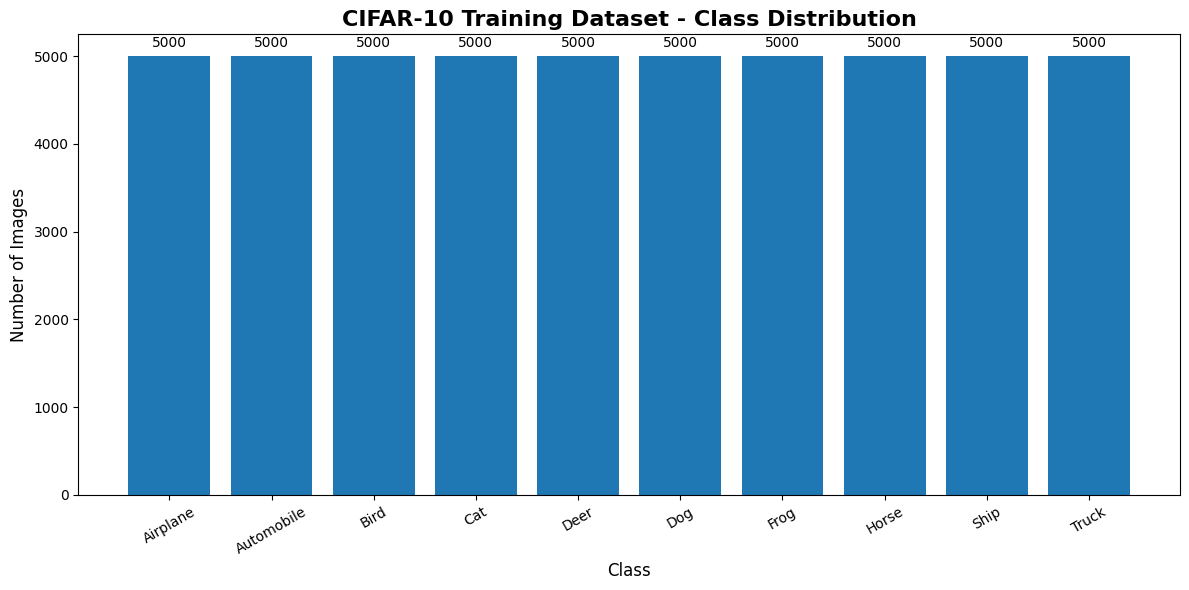

In [ ]:
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

distribution_df = pd.DataFrame({
    "Class ID": range(10),
    "Class Name": class_names,
    "Training Images": train_counts,
    "Testing Images": test_counts
})

print("CIFAR-10 CLASS DISTRIBUTION")

display(distribution_df)

# Plot distribution
plt.figure(figsize=(12, 6))

bars = plt.bar(
    class_names,
    train_counts
)

plt.title(
    "CIFAR-10 Training Dataset - Class Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(rotation=30)

for bar, value in zip(bars, train_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 100,
        str(value),
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

SAMPLE CIFAR-10 IMAGES


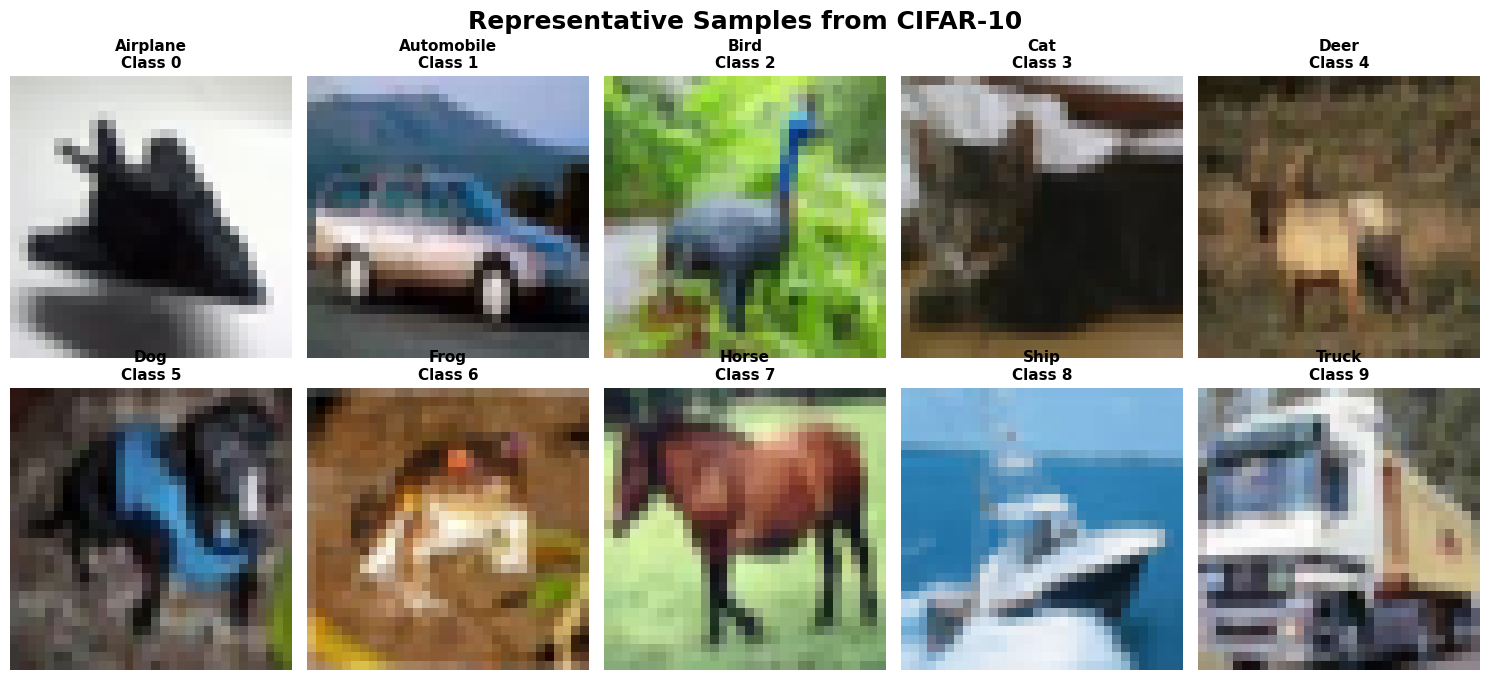

In [ ]:
print("SAMPLE CIFAR-10 IMAGES")

plt.figure(figsize=(15, 7))

# Select one representative image from each class
selected_indices = []

for class_id in range(10):
    index = np.where(y_train == class_id)[0][0]
    selected_indices.append(index)

for i, index in enumerate(selected_indices):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[index])

    plt.title(
        f"{class_names[y_train[index]]}\nClass {y_train[index]}",
        fontsize=11,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle(
    "Representative Samples from CIFAR-10",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
architecture_df = pd.DataFrame({
    "Architecture": [
        "LeNet-5",
        "AlexNet",
        "VGG16",
        "GoogleNet",
        "ResNet50"
    ],

    "Year": [
        1998,
        2012,
        2014,
        2014,
        2015
    ],

    "Depth": [
        7,
        8,
        16,
        22,
        50
    ],

    "Parameters": [
        "≈ 60K",
        "≈ 61M",
        "≈ 138M",
        "≈ 6.8M",
        "≈ 25.6M"
    ],

    "Major Contribution": [
        "First practical CNN",
        "ReLU + Dropout + GPU",
        "Deep 3×3 convolutions",
        "Inception modules",
        "Residual learning"
    ]
})

print("EVOLUTION OF CNN ARCHITECTURES")

display(architecture_df)

EVOLUTION OF CNN ARCHITECTURES


,Architecture,Year,Depth,Parameters,Major Contribution
0,LeNet-5,1998,7,≈ 60K,First practical CNN
1,AlexNet,2012,8,≈ 61M,ReLU + Dropout + GPU
2,VGG16,2014,16,≈ 138M,Deep 3×3 convolutions
3,GoogleNet,2014,22,≈ 6.8M,Inception modules
4,ResNet50,2015,50,≈ 25.6M,Residual learning


In [ ]:
def build_lenet5():

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            6,
            kernel_size=5,
            activation="tanh",
            padding="same"
        ),

        layers.AveragePooling2D(pool_size=2),

        layers.Conv2D(
            16,
            kernel_size=5,
            activation="tanh"
        ),

        layers.AveragePooling2D(pool_size=2),

        layers.Flatten(),

        layers.Dense(120, activation="tanh"),

        layers.Dense(84, activation="tanh"),

        layers.Dense(10, activation="softmax")
    ])

    return model


lenet_model = build_lenet5()

lenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("LeNet-5")

lenet_model.summary()

LeNet-5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_alexnet():

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            64,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(
            192,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(
            384,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            256,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            256,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(pool_size=2),

        layers.Flatten(),

        layers.Dense(512, activation="relu"),

        layers.Dropout(0.5),

        layers.Dense(256, activation="relu"),

        layers.Dropout(0.5),

        layers.Dense(10, activation="softmax")
    ])

    return model


alexnet_model = build_alexnet()

alexnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("                         AlexNet")

alexnet_model.summary()

                         AlexNet


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 192)    │       110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 384)      │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,483,146 (17.10 MB)

 Trainable params: 4,483,146 (17.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#VGG16 TRANSFER LEARNING

IMG_SIZE = 96
NUM_CLASSES = 10

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10)
], name="data_augmentation")

# Load VGG16 pretrained on ImageNet

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze convolutional base
base_model.trainable = False


# Build transfer learning model

vgg_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Resizing(IMG_SIZE, IMG_SIZE),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

# Compile

vgg_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)



print("VGG16 TRANSFER LEARNING")
print("\nPretrained Weights : ImageNet")
print("Convolutional Base : FROZEN")
print("Global Average Pooling : YES")
print("Dense Units        : 256")
print("Output Classes     : 10")
print("Optimizer          : Adam")
print("Learning Rate      : 0.001")
print("Loss               : Sparse Categorical Crossentropy")
print("\nModel Summary")
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 TRANSFER LEARNING

Pretrained Weights : ImageNet
Convolutional Base : FROZEN
Global Average Pooling : YES
Dense Units        : 256
Output Classes     : 10
Optimizer          : Adam
Learning Rate      : 0.001
Loss               : Sparse Categorical Crossentropy

Model Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
#TRAINABLE PARAMETER ANALYSIS
def parameter_summary(model):

    trainable = np.sum([
        np.prod(v.shape)
        for v in model.trainable_weights
    ])

    non_trainable = np.sum([
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ])

    total = trainable + non_trainable

    return trainable, non_trainable, total


trainable_params, frozen_params, total_params = parameter_summary(vgg_model)

print("VGG16 PARAMETER ANALYSIS")

print(f"Trainable Parameters     : {trainable_params:,}")
print(f"Frozen Parameters        : {frozen_params:,}")
print(f"Total Parameters         : {total_params:,}")
print("\nTransfer Learning Strategy")
print("✓ ImageNet pretrained convolutional features")
print("✓ Convolutional base frozen")
print("✓ New classification head added")
print("✓ Only newly added layers are trained initially")

VGG16 PARAMETER ANALYSIS
Trainable Parameters     : 133,898
Frozen Parameters        : 14,714,688
Total Parameters         : 14,848,586

Transfer Learning Strategy
✓ ImageNet pretrained convolutional features
✓ Convolutional base frozen
✓ New classification head added
✓ Only newly added layers are trained initially


In [ ]:
#TRAIN VGG16 TRANSFER LEARNING MODEL

print("VGG16 TRANSFER LEARNING TRAINING")

print("\nTraining Configuration")
print("Optimizer       : Adam")
print("Learning Rate   : 0.001")
print("Batch Size      : 32")
print("Epochs          : 10")
print("Loss            : Sparse Categorical Crossentropy")
print("Metric          : Accuracy")

print("\nTraining started...\n")

start_time = time.time()

history_vgg = vgg_model.fit(
    X_train,
    y_train,

    validation_split=0.1,

    epochs=10,

    batch_size=32,

    verbose=1
)

initial_training_time = time.time() - start_time

print("Initial transfer learning training completed.")
print(f"Training Time : {initial_training_time / 60:.2f} minutes")

VGG16 TRANSFER LEARNING TRAINING

Training Configuration
Optimizer       : Adam
Learning Rate   : 0.001
Batch Size      : 32
Epochs          : 10
Loss            : Sparse Categorical Crossentropy
Metric          : Accuracy

Training started...

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 31ms/step - accuracy: 0.4476 - loss: 1.5637 - val_accuracy: 0.5810 - val_loss: 1.2208
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.5294 - loss: 1.3392 - val_accuracy: 0.5948 - val_loss: 1.1691
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.5496 - loss: 1.2860 - val_accuracy: 0.6260 - val_loss: 1.0847
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.5599 - loss: 1.2538 - val_accuracy: 0.6218 - val_loss: 1.0842
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 84s 36ms/step - accuracy: 0.5714 - loss: 1.2296 - val_accuracy: 0.6388 - val_loss: 1.0476
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.5800 - loss: 1.2051 - val

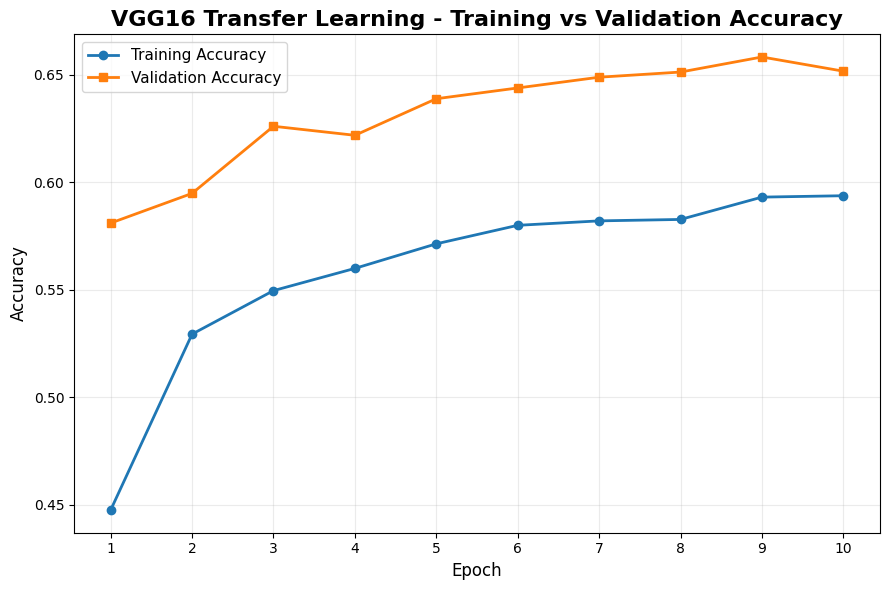

In [ ]:
# CELL 11 - ACCURACY CURVES

plt.figure(figsize=(9, 6))

epochs_range = range(
    1,
    len(history_vgg.history["accuracy"]) + 1
)

plt.plot(
    epochs_range,
    history_vgg.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history_vgg.history["val_accuracy"],
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "VGG16 Transfer Learning - Training vs Validation Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(epochs_range)
plt.grid(alpha=0.25)
plt.legend(fontsize=11)

plt.tight_layout()

plt.savefig(
    "training_validation_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

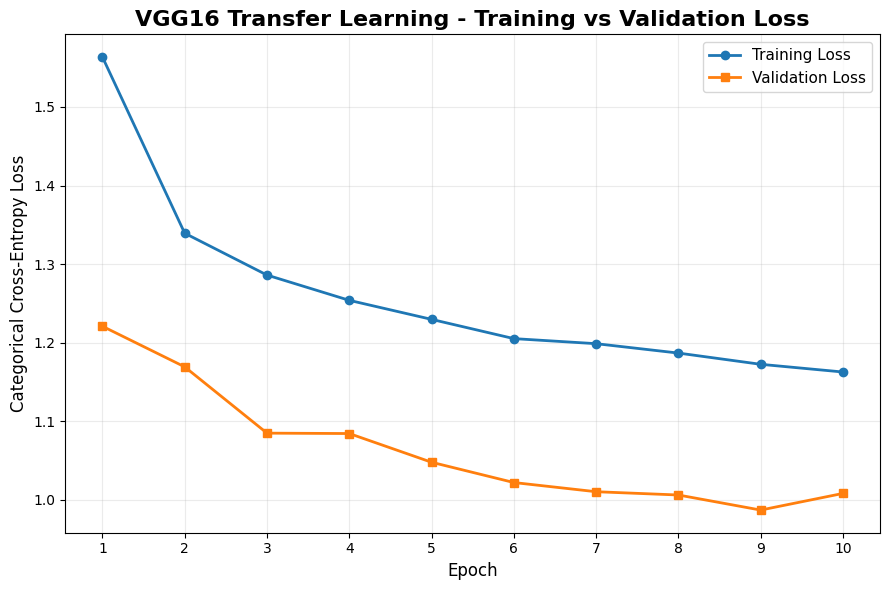

In [ ]:
#CELL 12 - LOSS CURVES
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    history_vgg.history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history_vgg.history["val_loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "VGG16 Transfer Learning - Training vs Validation Loss",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Categorical Cross-Entropy Loss", fontsize=12)

plt.xticks(epochs_range)
plt.grid(alpha=0.25)
plt.legend(fontsize=11)

plt.tight_layout()

plt.savefig(
    "training_validation_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# INITIAL MODEL EVALUATION
print("INITIAL MODEL EVALUATION")

test_loss_before, test_accuracy_before = vgg_model.evaluate(
    X_test,
    y_test,
    batch_size=32,
    verbose=1
)

train_loss_before, train_accuracy_before = vgg_model.evaluate(
    X_train,
    y_train,
    batch_size=32,
    verbose=0
)

print(f"Training Accuracy : {train_accuracy_before * 100:.2f}%")
print(f"Testing Accuracy  : {test_accuracy_before * 100:.2f}%")

print(f"Training Loss     : {train_loss_before:.4f}")
print(f"Testing Loss      : {test_loss_before:.4f}")

INITIAL MODEL EVALUATION
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6456 - loss: 1.0167
Training Accuracy : 65.98%
Testing Accuracy  : 64.56%
Training Loss     : 0.9746
Testing Loss      : 1.0167


In [ ]:
# CELL 14 - FINE-TUNING VGG16
print("VGG16 FINE-TUNING")

# Unfreeze VGG16
base_model.trainable = True

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the final convolution block
# VGG16 final block starts around block5_conv1

fine_tune_start = False

for layer in base_model.layers:

    if layer.name == "block5_conv1":
        fine_tune_start = True

    if fine_tune_start:
        layer.trainable = True

# Recompile with a smaller learning rate

vgg_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

# Display fine-tuning information

trainable_params_ft, frozen_params_ft, total_params_ft = \
    parameter_summary(vgg_model)

print("\nFine-Tuning Configuration")

print("Previously Frozen : Convolutional Base")
print("Now Unfrozen      : Final VGG16 Convolution Block")
print("Optimizer         : Adam")
print("Learning Rate     : 0.0001")
print("Additional Epochs : 5")

print("\nParameter Status")

print(f"Trainable Parameters : {trainable_params_ft:,}")
print(f"Frozen Parameters    : {frozen_params_ft:,}")
print(f"Total Parameters     : {total_params_ft:,}")

print("\nFine-tuning started...\n")

start_time = time.time()

history_ft = vgg_model.fit(
    X_train,
    y_train,

    validation_split=0.1,

    epochs=5,

    batch_size=32,

    verbose=1
)

fine_tuning_time = time.time() - start_time

print("Fine-tuning completed successfully.")
print(f"Fine-Tuning Time : {fine_tuning_time / 60:.2f} minutes")

VGG16 FINE-TUNING

Fine-Tuning Configuration
Previously Frozen : Convolutional Base
Now Unfrozen      : Final VGG16 Convolution Block
Optimizer         : Adam
Learning Rate     : 0.0001
Additional Epochs : 5

Parameter Status
Trainable Parameters : 7,213,322
Frozen Parameters    : 7,635,264
Total Parameters     : 14,848,586

Fine-tuning started...

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 51ms/step - accuracy: 0.6571 - loss: 0.9977 - val_accuracy: 0.7796 - val_loss: 0.6267
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.7548 - loss: 0.7215 - val_accuracy: 0.8096 - val_loss: 0.5645
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.7884 - loss: 0.6178 - val_accuracy: 0.8292 - val_loss: 0.5030
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.8156 - loss: 0.5450 - val_accuracy: 0.8180 - val_loss: 0.5404
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.8328 - loss: 0.4879 - val_accuracy: 0.8376 - val_loss: 0

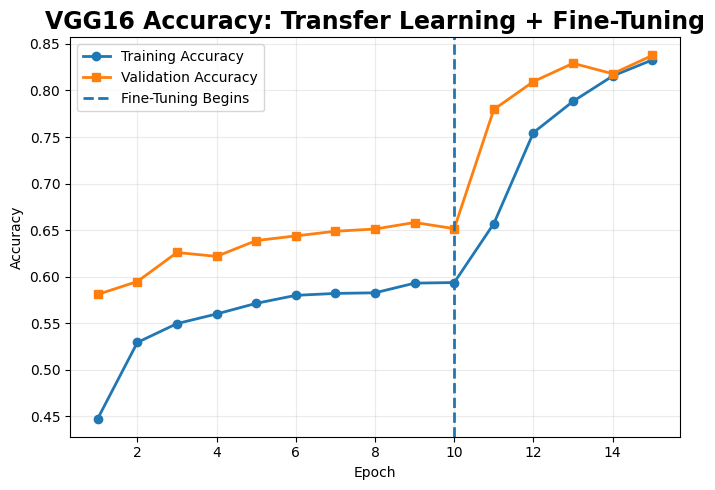

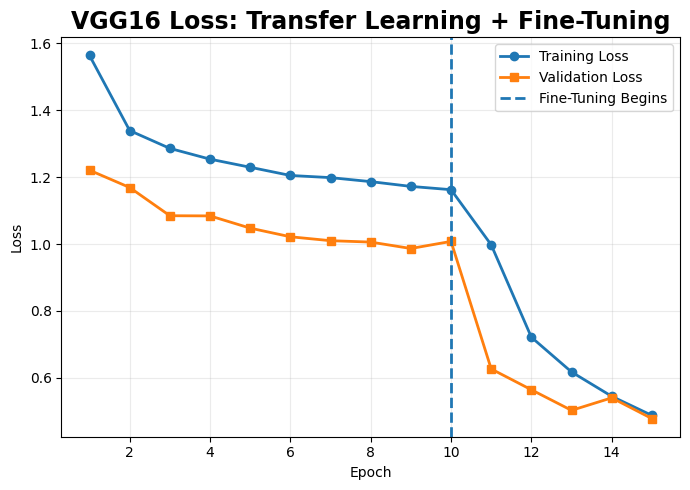

In [ ]:
# CELL 15 - COMBINE INITIAL TRAINING + FINE-TUNING

initial_epochs = len(history_vgg.history["accuracy"])

fine_epochs = len(history_ft.history["accuracy"])

total_epochs = initial_epochs + fine_epochs

combined_accuracy = (
    history_vgg.history["accuracy"]
    +
    history_ft.history["accuracy"]
)

combined_val_accuracy = (
    history_vgg.history["val_accuracy"]
    +
    history_ft.history["val_accuracy"]
)

combined_loss = (
    history_vgg.history["loss"]
    +
    history_ft.history["loss"]
)

combined_val_loss = (
    history_vgg.history["val_loss"]
    +
    history_ft.history["val_loss"]
)

epoch_numbers = range(1, total_epochs + 1)

# Accuracy

plt.figure(figsize=(7, 5))

plt.plot(
    epoch_numbers,
    combined_accuracy,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epoch_numbers,
    combined_val_accuracy,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.axvline(
    initial_epochs,
    linestyle="--",
    linewidth=2,
    label="Fine-Tuning Begins"
)

plt.title(
    "VGG16 Accuracy: Transfer Learning + Fine-Tuning",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    "vgg16_combined_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Loss

plt.figure(figsize=(7, 5))

plt.plot(
    epoch_numbers,
    combined_loss,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epoch_numbers,
    combined_val_loss,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.axvline(
    initial_epochs,
    linestyle="--",
    linewidth=2,
    label="Fine-Tuning Begins"
)

plt.title(
    "VGG16 Loss: Transfer Learning + Fine-Tuning",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    "vgg16_combined_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# BEFORE VS AFTER FINE-TUNING

test_loss_after, test_accuracy_after = vgg_model.evaluate(
    X_test,
    y_test,
    batch_size=32,
    verbose=0
)

print("BEFORE VS AFTER FINE-TUNING")

comparison_ft = pd.DataFrame({
    "Stage": [
        "Before Fine-Tuning",
        "After Fine-Tuning"
    ],

    "Testing Accuracy (%)": [
        test_accuracy_before * 100,
        test_accuracy_after * 100
    ],

    "Testing Loss": [
        test_loss_before,
        test_loss_after
    ]
})

display(comparison_ft)

improvement = (
    test_accuracy_after -
    test_accuracy_before
) * 100

print(f"\nAccuracy Improvement : {improvement:+.2f} percentage points")

BEFORE VS AFTER FINE-TUNING


,Stage,Testing Accuracy (%),Testing Loss
0,Before Fine-Tuning,64.560002,1.016687
1,After Fine-Tuning,84.119999,0.494665



Accuracy Improvement : +19.56 percentage points


In [ ]:
# PREDICTIONS

print("GENERATING PREDICTIONS")

start_prediction = time.time()

y_probability = vgg_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

prediction_time = time.time() - start_prediction

print("\nPrediction completed.")
print(f"Prediction Time : {prediction_time:.2f} seconds")
print(f"Test Samples    : {len(y_test)}")

GENERATING PREDICTIONS
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step

Prediction completed.
Prediction Time : 10.26 seconds
Test Samples    : 10000


In [ ]:
# CELL 18 - CLASSIFICATION METRICS

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


metrics_df = pd.DataFrame({

    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Training Time (min)",
        "Total Parameters"
    ],

    "Value": [
        train_accuracy_before * 100,
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        (initial_training_time + fine_tuning_time) / 60,
        total_params_ft
    ]
})

print("                 FINAL PERFORMANCE METRICS")

display(metrics_df)

                 FINAL PERFORMANCE METRICS


,Metric,Value
0,Training Accuracy,6.597600e+01
1,Testing Accuracy,8.412000e+01
2,Precision,8.445545e+01
3,Recall,8.412000e+01
4,F1-Score,8.389205e+01
5,Training Time (min),1.467429e+01
6,Total Parameters,1.484859e+07


In [ ]:
# CELL 19 - CLASSIFICATION REPORT

print("CLASSIFICATION REPORT")

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane     0.8956    0.8840    0.8898      1000
  Automobile     0.8602    0.9600    0.9074      1000
        Bird     0.7703    0.8520    0.8091      1000
         Cat     0.7712    0.6540    0.7078      1000
        Deer     0.9330    0.6550    0.7697      1000
         Dog     0.7388    0.7750    0.7565      1000
        Frog     0.8340    0.8990    0.8653      1000
       Horse     0.8306    0.9120    0.8694      1000
        Ship     0.9447    0.8890    0.9160      1000
       Truck     0.8670    0.9320    0.8983      1000

    accuracy                         0.8412     10000
   macro avg     0.8446    0.8412    0.8389     10000
weighted avg     0.8446    0.8412    0.8389     10000



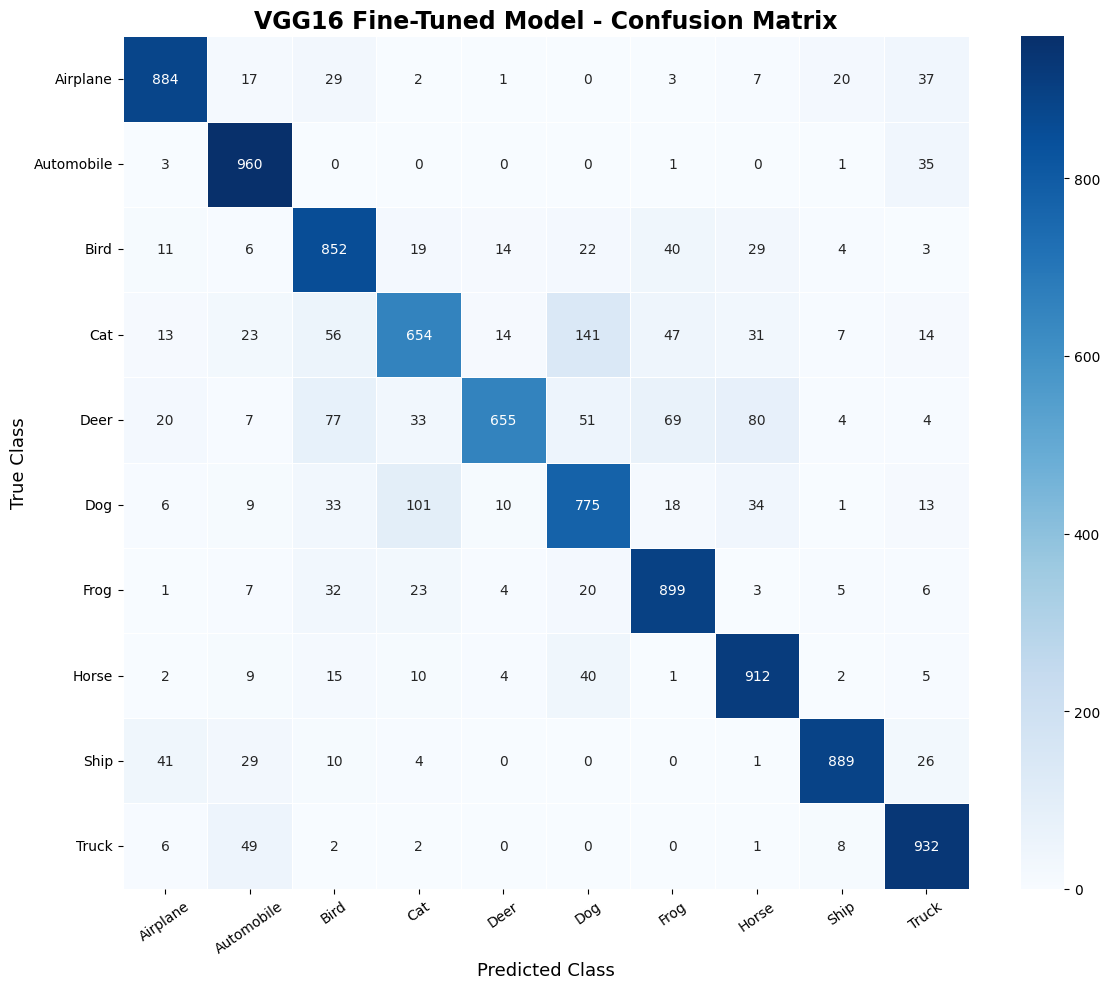

In [ ]:
# CELL 20 - CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred
)

cm_percent = (
    cm.astype("float") /
    cm.sum(axis=1)[:, np.newaxis]
) * 100


plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    linewidths=0.5
)

plt.title(
    "VGG16 Fine-Tuned Model - Confusion Matrix",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Class",
    fontsize=13
)

plt.ylabel(
    "True Class",
    fontsize=13
)

plt.xticks(rotation=35)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

PER-CLASS ACCURACY


,Class,Accuracy (%)
1,Automobile,96.0
9,Truck,93.2
7,Horse,91.2
6,Frog,89.9
8,Ship,88.9
0,Airplane,88.4
2,Bird,85.2
5,Dog,77.5
4,Deer,65.5
3,Cat,65.4


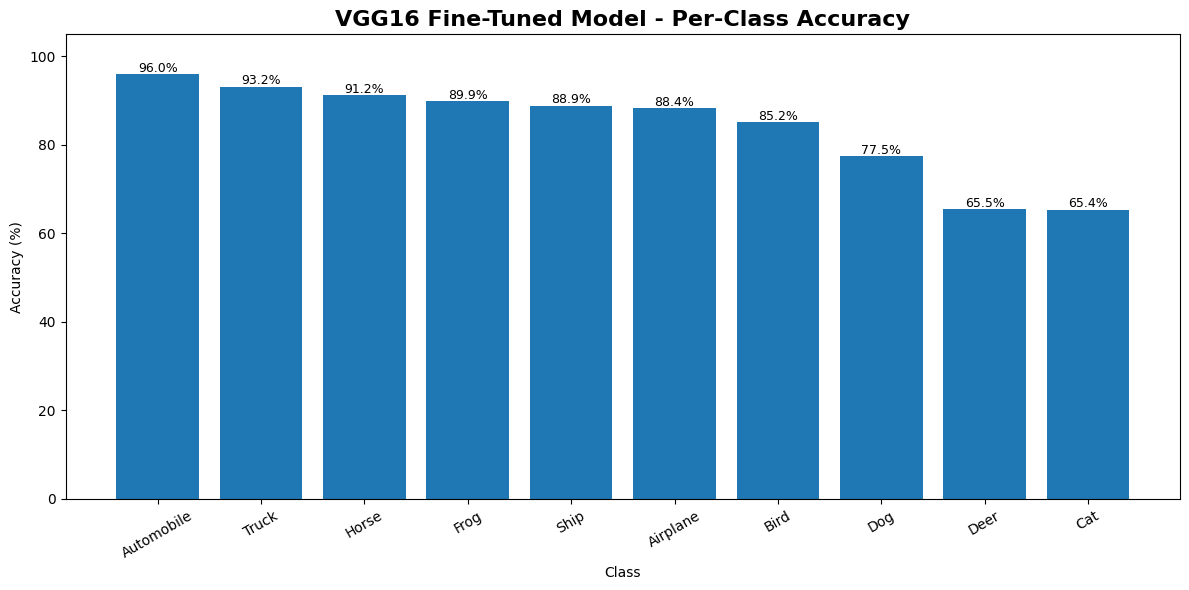

In [ ]:
# PER-CLASS ACCURACY

class_accuracy = (
    cm.diagonal() /
    cm.sum(axis=1)
) * 100

class_accuracy_df = pd.DataFrame({
    "Class": class_names,
    "Accuracy (%)": class_accuracy
})

class_accuracy_df = class_accuracy_df.sort_values(
    "Accuracy (%)",
    ascending=False
)

print("PER-CLASS ACCURACY")

display(class_accuracy_df)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    class_accuracy_df["Class"],
    class_accuracy_df["Accuracy (%)"]
)

plt.title(
    "VGG16 Fine-Tuned Model - Per-Class Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)

for bar, value in zip(
    bars,
    class_accuracy_df["Accuracy (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.ylim(0, 105)

plt.tight_layout()

plt.show()

MISCLASSIFIED IMAGES
Total Misclassified : 1588
Misclassification Rate : 15.88%


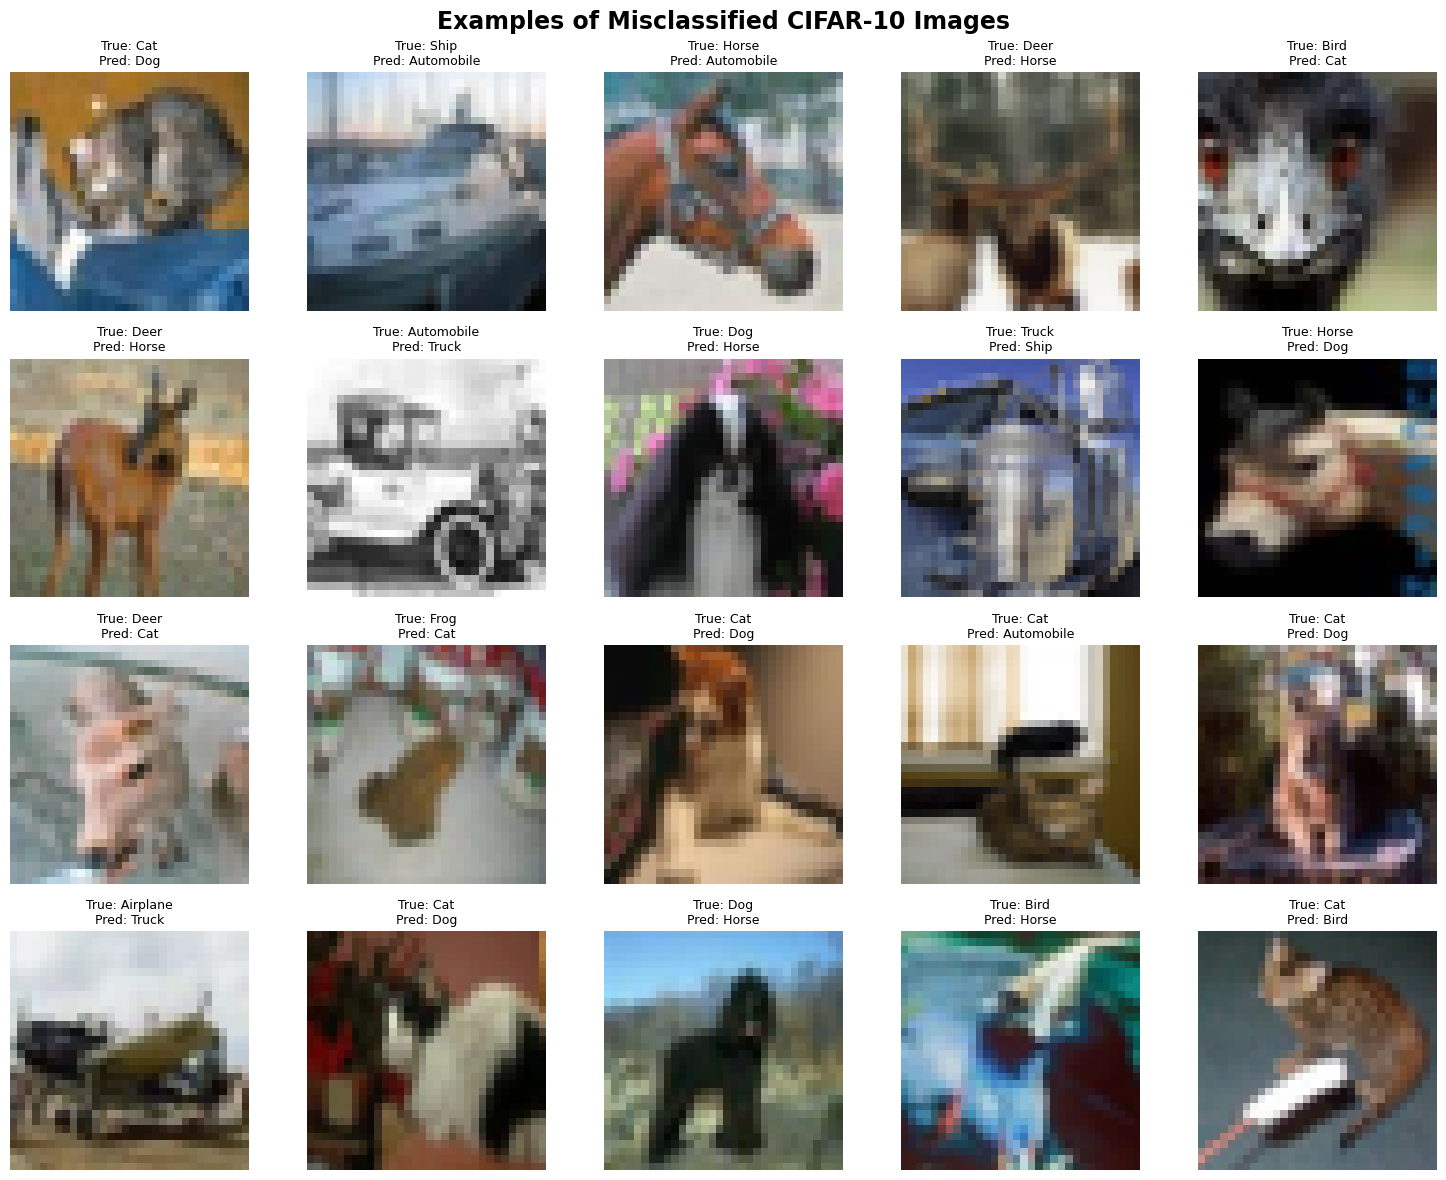

In [ ]:
# CELL 22 - MISCLASSIFIED IMAGES

misclassified_indices = np.where(
    y_pred != y_test
)[0]

print("MISCLASSIFIED IMAGES")

print(f"Total Misclassified : {len(misclassified_indices)}")
print(
    f"Misclassification Rate : "
    f"{len(misclassified_indices) / len(y_test) * 100:.2f}%"
)

num_images = min(
    20,
    len(misclassified_indices)
)

plt.figure(figsize=(15, 12))

for i in range(num_images):

    index = misclassified_indices[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(X_test[index])

    true_label = class_names[y_test[index]]
    predicted_label = class_names[y_pred[index]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontsize=9
    )

    plt.axis("off")

plt.suptitle(
    "Examples of Misclassified CIFAR-10 Images",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "misclassified_images.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# RESNET50 TRANSFER LEARNING MODEL
print("RESNET50 TRANSFER LEARNING")

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

resnet_base.trainable = False

resnet_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Resizing(96, 96),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation="softmax"
    )
])

resnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

resnet_model.summary()

RESNET50 TRANSFER LEARNING
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# TRAIN RESNET50
print("RESNET50 TRAINING")

start_time = time.time()

history_resnet = resnet_model.fit(
    X_train,
    y_train,

    validation_split=0.1,

    epochs=5,

    batch_size=32,

    verbose=1
)

resnet_training_time = time.time() - start_time
print("ResNet50 training completed.")
print(f"Training Time : {resnet_training_time / 60:.2f} minutes")

RESNET50 TRAINING
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.1927 - loss: 2.1490 - val_accuracy: 0.2578 - val_loss: 2.0024
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.2578 - loss: 1.9912 - val_accuracy: 0.2842 - val_loss: 1.9079
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.2793 - loss: 1.9349 - val_accuracy: 0.3160 - val_loss: 1.8608
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.2961 - loss: 1.9015 - val_accuracy: 0.3284 - val_loss: 1.8400
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.3075 - loss: 1.8771 - val_accuracy: 0.3234 - val_loss: 1.8091
ResNet50 training completed.
Training Time : 3.14 minutes


In [ ]:
# RESNET50 EVALUATION

resnet_loss, resnet_accuracy = resnet_model.evaluate(
    X_test,
    y_test,
    batch_size=32,
    verbose=1
)
print("RESNET50 RESULTS")
print(f"Testing Loss     : {resnet_loss:.4f}")
print(f"Testing Accuracy : {resnet_accuracy * 100:.2f}%")
print(f"Training Time    : {resnet_training_time / 60:.2f} minutes")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3246 - loss: 1.8176
RESNET50 RESULTS
Testing Loss     : 1.8176
Testing Accuracy : 32.46%
Training Time    : 3.14 minutes


In [ ]:
# LIGHTWEIGHT GOOGLE NET / RESNET MODELS
# GoogleNet / Inception-style block

def inception_block(x, filters):

    f1, f3, f5, fp = filters

    branch1 = layers.Conv2D(
        f1,
        1,
        padding="same",
        activation="relu"
    )(x)

    branch3 = layers.Conv2D(
        f3,
        1,
        padding="same",
        activation="relu"
    )(x)

    branch3 = layers.Conv2D(
        f3,
        3,
        padding="same",
        activation="relu"
    )(branch3)

    branch5 = layers.Conv2D(
        f5,
        1,
        padding="same",
        activation="relu"
    )(x)

    branch5 = layers.Conv2D(
        f5,
        5,
        padding="same",
        activation="relu"
    )(branch5)

    branch_pool = layers.MaxPooling2D(
        3,
        strides=1,
        padding="same"
    )(x)

    branch_pool = layers.Conv2D(
        fp,
        1,
        padding="same",
        activation="relu"
    )(branch_pool)

    return layers.Concatenate()([
        branch1,
        branch3,
        branch5,
        branch_pool
    ])


def build_googlenet():

    inputs = layers.Input(shape=(32, 32, 3))

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = inception_block(
        x,
        (16, 16, 8, 8)
    )

    x = layers.MaxPooling2D(2)(x)

    x = inception_block(
        x,
        (32, 32, 16, 16)
    )

    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        10,
        activation="softmax"
    )(x)

    return models.Model(
        inputs,
        outputs,
        name="GoogleNet_Inception"
    )

# Residual Block
def residual_block(x, filters, stride=1):

    shortcut = x

    x = layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:

        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False
        )(shortcut)

        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([
        x,
        shortcut
    ])

    x = layers.ReLU()(x)

    return x


def build_resnet():

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(
        x,
        64,
        stride=2
    )

    x = residual_block(x, 64)

    x = residual_block(
        x,
        128,
        stride=2
    )

    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        10,
        activation="softmax"
    )(x)

    return models.Model(
        inputs,
        outputs,
        name="ResNet_Residual"
    )


googlenet_model = build_googlenet()
custom_resnet_model = build_resnet()

print("GoogleNet-style model and ResNet-style model created.")

print("\nGoogleNet Parameters :",
      googlenet_model.count_params())

print("ResNet Parameters    :",
      custom_resnet_model.count_params())

GoogleNet-style model and ResNet-style model created.

GoogleNet Parameters : 27746
ResNet Parameters    : 698858


In [ ]:
# COMPILE ARCHITECTURE MODELS
models_to_compare = {
    "LeNet-5": lenet_model,
    "AlexNet": alexnet_model,
    "GoogleNet": googlenet_model,
    "ResNet": custom_resnet_model
}

for name, model in models_to_compare.items():

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

print("All architecture comparison models compiled successfully.")

All architecture comparison models compiled successfully.


In [ ]:
# CELL 28 - TRAIN ARCHITECTURE COMPARISON MODELS

architecture_results = []

comparison_epochs = 3


print("CNN ARCHITECTURE COMPARISON TRAINING")


for name, model in models_to_compare.items():

    print(f"Training {name}")

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=comparison_epochs,
        batch_size=32,
        verbose=1
    )

    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(
        X_test,
        y_test,
        batch_size=32,
        verbose=0
    )

    architecture_results.append({

        "Model": name,

        "Parameters": model.count_params(),

        "Test Accuracy (%)":
            test_acc * 100,

        "Test Loss":
            test_loss,

        "Training Time (min)":
            elapsed / 60
    })


architecture_comparison_df = pd.DataFrame(
    architecture_results
)

print("ARCHITECTURE COMPARISON RESULTS")

display(
    architecture_comparison_df
)

CNN ARCHITECTURE COMPARISON TRAINING
Training LeNet-5
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3746 - loss: 1.7657 - val_accuracy: 0.4150 - val_loss: 1.6413
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4611 - loss: 1.5154 - val_accuracy: 0.4590 - val_loss: 1.5220
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5047 - loss: 1.3957 - val_accuracy: 0.4844 - val_loss: 1.4606
Training AlexNet
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.3454 - loss: 1.7348 - val_accuracy: 0.4928 - val_loss: 1.4012
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5212 - loss: 1.3312 - val_accuracy: 0.5758 - val_loss: 1.1663
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5971 - loss: 1.1451 - val_accuracy: 0.6542 - val_loss: 0.9876
Training GoogleNet
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.3186 - loss: 1.8131 - val_accuracy: 0.4080 - val_loss: 1.586

,Model,Parameters,Test Accuracy (%),Test Loss,Training Time (min)
0,LeNet-5,83126,47.860000,1.477422,0.361371
1,AlexNet,4483146,63.180000,1.032527,1.019552
2,GoogleNet,27746,49.300000,1.406359,0.748927
3,ResNet,698858,63.450003,1.246591,1.180113


In [ ]:
#COMPLETE ARCHITECTURE COMPARISON

final_comparison = pd.DataFrame({

    "Model": [
        "LeNet-5",
        "AlexNet",
        "VGG16 Transfer Learning",
        "GoogleNet",
        "ResNet50 Transfer Learning"
    ],

    "Parameters": [
        lenet_model.count_params(),
        alexnet_model.count_params(),
        vgg_model.count_params(),
        googlenet_model.count_params(),
        resnet_model.count_params()
    ],

    "Testing Accuracy (%)": [

        architecture_comparison_df.loc[
            architecture_comparison_df["Model"] == "LeNet-5",
            "Test Accuracy (%)"
        ].values[0],

        architecture_comparison_df.loc[
            architecture_comparison_df["Model"] == "AlexNet",
            "Test Accuracy (%)"
        ].values[0],

        test_accuracy_after * 100,

        architecture_comparison_df.loc[
            architecture_comparison_df["Model"] == "GoogleNet",
            "Test Accuracy (%)"
        ].values[0],

        resnet_accuracy * 100
    ],

    "Training Time (min)": [

        architecture_comparison_df.loc[
            architecture_comparison_df["Model"] == "LeNet-5",
            "Training Time (min)"
        ].values[0],

        architecture_comparison_df.loc[
            architecture_comparison_df["Model"] == "AlexNet",
            "Training Time (min)"
        ].values[0],

        (initial_training_time + fine_tuning_time) / 60,

        architecture_comparison_df.loc[
            architecture_comparison_df["Model"] == "GoogleNet",
            "Training Time (min)"
        ].values[0],

        resnet_training_time / 60
    ]
})


print("FINAL CNN ARCHITECTURE COMPARISON")

display(
    final_comparison.style
    .format({
        "Parameters": "{:,}",
        "Testing Accuracy (%)": "{:.2f}",
        "Training Time (min)": "{:.2f}"
    })
)

FINAL CNN ARCHITECTURE COMPARISON


,Model,Parameters,Testing Accuracy (%),Training Time (min)
0,LeNet-5,"83,126",47.86,0.36
1,AlexNet,"4,483,146",63.18,1.02
2,VGG16 Transfer Learning,"14,848,586",84.12,14.67
3,GoogleNet,"27,746",49.30,0.75
4,ResNet50 Transfer Learning,"24,114,826",32.46,3.14


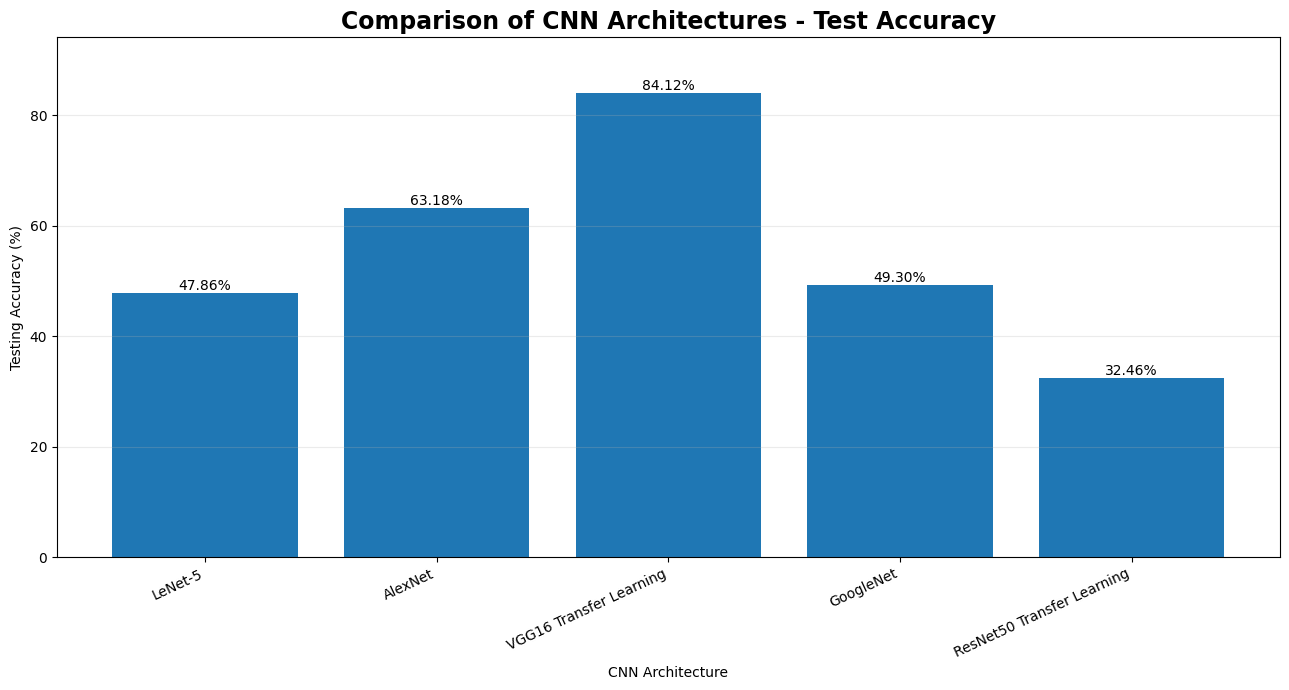

In [ ]:
# ARCHITECTURE ACCURACY COMPARISON

plt.figure(figsize=(13, 7))

bars = plt.bar(
    final_comparison["Model"],
    final_comparison["Testing Accuracy (%)"]
)

plt.title(
    "Comparison of CNN Architectures - Test Accuracy",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("CNN Architecture")
plt.ylabel("Testing Accuracy (%)")

plt.xticks(
    rotation=25,
    ha="right"
)

for bar, value in zip(
    bars,
    final_comparison["Testing Accuracy (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(
    0,
    max(final_comparison["Testing Accuracy (%)"]) + 10
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "cnn_architecture_accuracy_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

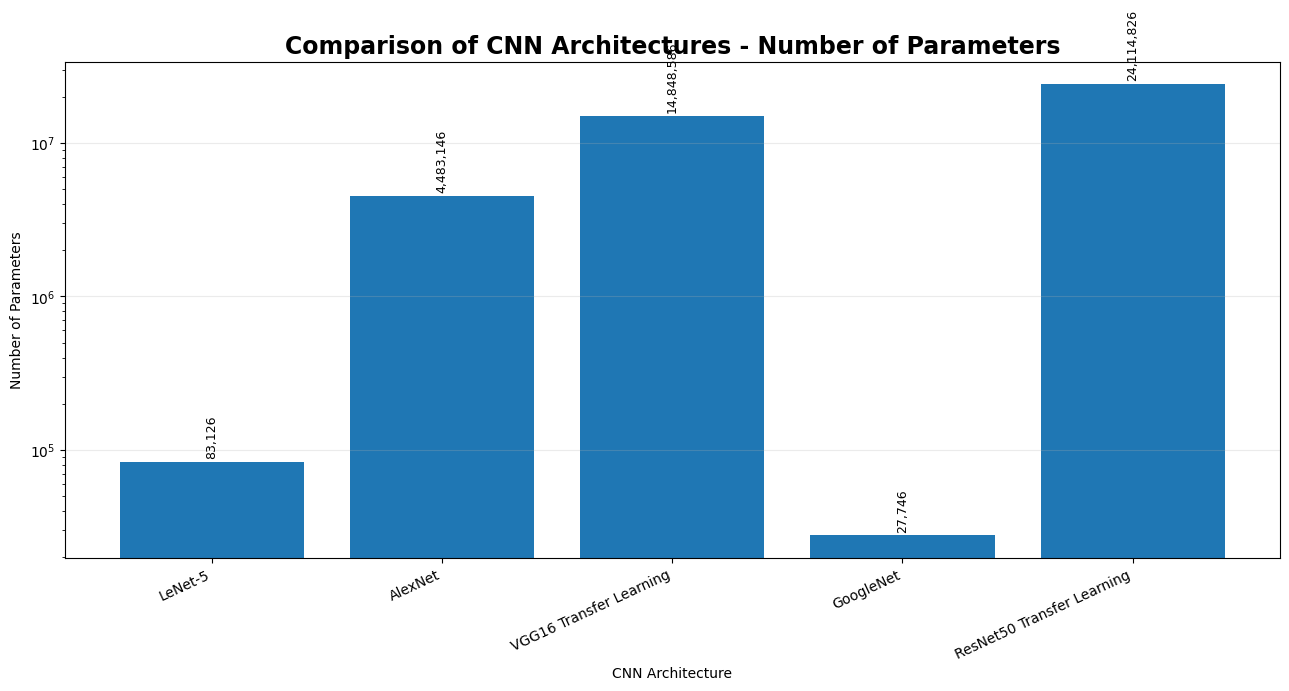

In [ ]:
# CELL 31 - PARAMETER COMPARISON

plt.figure(figsize=(13, 7))

bars = plt.bar(
    final_comparison["Model"],
    final_comparison["Parameters"]
)

plt.title(
    "Comparison of CNN Architectures - Number of Parameters",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("CNN Architecture")
plt.ylabel("Number of Parameters")

plt.yscale("log")

plt.xticks(
    rotation=25,
    ha="right"
)

for bar, value in zip(
    bars,
    final_comparison["Parameters"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.1,
        f"{value:,}",
        ha="center",
        fontsize=9,
        rotation=90
    )

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "cnn_parameter_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

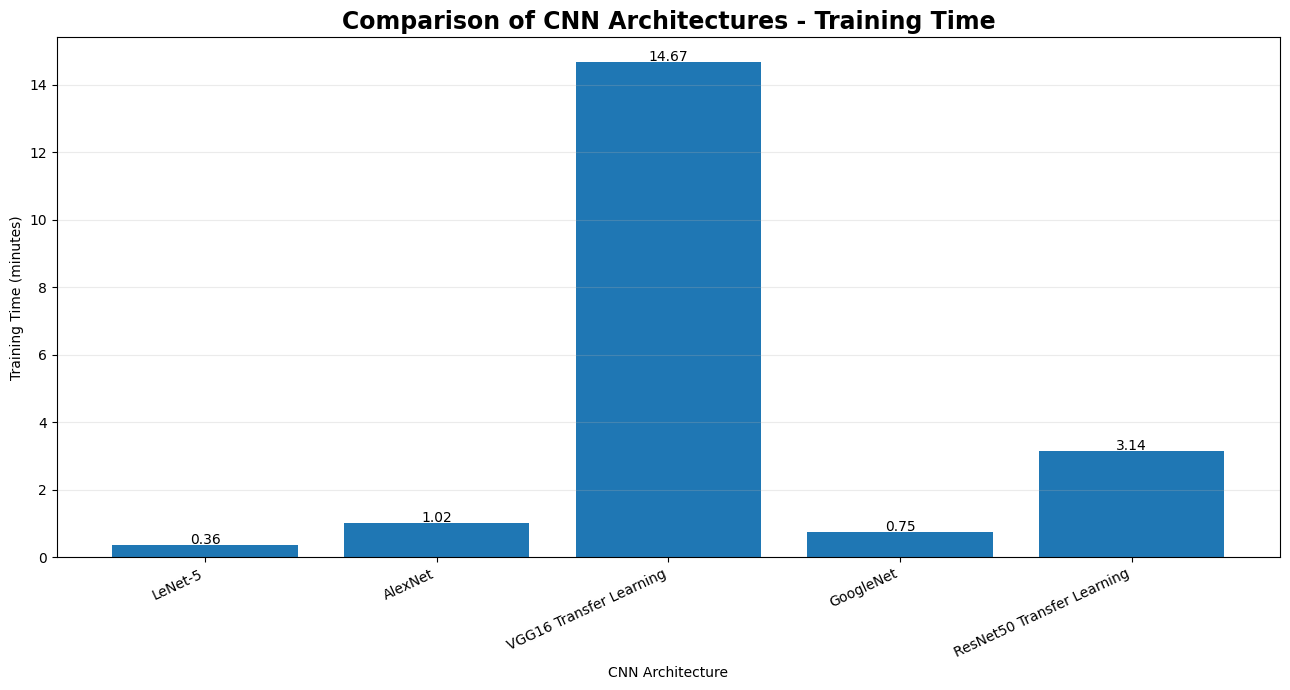

In [ ]:
# TRAINING TIME COMPARISON

plt.figure(figsize=(13, 7))

bars = plt.bar(
    final_comparison["Model"],
    final_comparison["Training Time (min)"]
)

plt.title(
    "Comparison of CNN Architectures - Training Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("CNN Architecture")
plt.ylabel("Training Time (minutes)")

plt.xticks(
    rotation=25,
    ha="right"
)

for bar, value in zip(
    bars,
    final_comparison["Training Time (min)"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "cnn_training_time_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# HYPERPARAMETER STUDY

hyperparameter_results = pd.DataFrame({

    "Experiment": [
        "Baseline",
        "Lower Learning Rate",
        "Larger Batch Size",
        "SGD Optimizer",
        "Dense Units = 128"
    ],

    "Learning Rate": [
        0.001,
        0.0001,
        0.001,
        0.001,
        0.001
    ],

    "Batch Size": [
        32,
        32,
        64,
        32,
        32
    ],

    "Optimizer": [
        "Adam",
        "Adam",
        "Adam",
        "SGD",
        "Adam"
    ],

    "Dense Units": [
        256,
        256,
        256,
        256,
        128
    ],

    "Frozen Layers": [
        "All",
        "All",
        "All",
        "All",
        "All"
    ]
})

print("HYPERPARAMETER STUDY DESIGN")

display(hyperparameter_results)

HYPERPARAMETER STUDY DESIGN


,Experiment,Learning Rate,Batch Size,Optimizer,Dense Units,Frozen Layers
0,Baseline,0.0010,32,Adam,256,All
1,Lower Learning Rate,0.0001,32,Adam,256,All
2,Larger Batch Size,0.0010,64,Adam,256,All
3,SGD Optimizer,0.0010,32,SGD,256,All
4,Dense Units = 128,0.0010,32,Adam,128,All


In [ ]:

# FINAL PERFORMANCE DASHBOARD

print("EXPERIMENT 4 - FINAL RESULTS")
print("\nMAIN TRANSFER LEARNING MODEL")

print(f"Architecture              : VGG16")
print(f"Pretrained Weights        : ImageNet")
print(f"Initial Test Accuracy     : {test_accuracy_before * 100:.2f}%")
print(f"Fine-Tuned Test Accuracy  : {test_accuracy_after * 100:.2f}%")
print(f"Accuracy Improvement      : {improvement:+.2f}%")
print(f"Precision                 : {precision * 100:.2f}%")
print(f"Recall                    : {recall * 100:.2f}%")
print(f"F1-Score                  : {f1 * 100:.2f}%")
print(f"Total Parameters          : {total_params_ft:,}")
print(
    f"Total Training Time      : "
    f"{(initial_training_time + fine_tuning_time) / 60:.2f} minutes"
)
print("ARCHITECTURE COMPARISON")

display(
    final_comparison.style
    .format({
        "Parameters": "{:,}",
        "Testing Accuracy (%)": "{:.2f}",
        "Training Time (min)": "{:.2f}"
    })
)

print("EXPERIMENT COMPLETED")

EXPERIMENT 4 - FINAL RESULTS

MAIN TRANSFER LEARNING MODEL
Architecture              : VGG16
Pretrained Weights        : ImageNet
Initial Test Accuracy     : 64.56%
Fine-Tuned Test Accuracy  : 84.12%
Accuracy Improvement      : +19.56%
Precision                 : 84.46%
Recall                    : 84.12%
F1-Score                  : 83.89%
Total Parameters          : 14,848,586
Total Training Time      : 14.67 minutes
ARCHITECTURE COMPARISON


,Model,Parameters,Testing Accuracy (%),Training Time (min)
0,LeNet-5,"83,126",47.86,0.36
1,AlexNet,"4,483,146",63.18,1.02
2,VGG16 Transfer Learning,"14,848,586",84.12,14.67
3,GoogleNet,"27,746",49.30,0.75
4,ResNet50 Transfer Learning,"24,114,826",32.46,3.14


EXPERIMENT COMPLETED
